In [1]:
from pathlib import Path
import pickle
import numpy as np
from sympy import lambdify


def _get_symbol(expr, name: str):
    """Find a SymPy symbol in an expression by name."""
    matches = [s for s in expr.free_symbols if str(s) == name]
    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one symbol named '{name}', found {matches}."
        )
    return matches[0]


def _carp_boundary_factor(n: float) -> float:
    """
    Boundary factor used in the notebook for the Carp / delta-P1 approximation.

    In the notebook this variable is called k.
    """
    return (
        -0.13755 * n**3
        + 4.3390 * n**2
        - 4.90466 * n
        + 1.6896
    )


def load_carp_Lp_function(carp_pickle_path: str | Path):
    """
    Load the symbolic Carp / delta-P1 derivative dA/dmu_a from carp.pickle
    and return a NumPy-compatible function.

    The pickle is expected to contain:
        (dA_dmu_a, dA_dmu_s_red)

    Returns
    -------
    callable
        Function with signature:
            Lp_func(mu_a, mu_s_red, g, n)
    """
    carp_pickle_path = Path(carp_pickle_path)

    with carp_pickle_path.open("rb") as f:
        dA_dmu_a, _dA_dmu_s_red = pickle.load(f)

    mu_a_sym = _get_symbol(dA_dmu_a, "mu_a")
    mu_s_red_sym = _get_symbol(dA_dmu_a, "mu_s_red")
    g_sym = _get_symbol(dA_dmu_a, "g")
    k_sym = _get_symbol(dA_dmu_a, "k")

    dA_dmu_a_np = lambdify(
        (mu_a_sym, mu_s_red_sym, g_sym, k_sym),
        dA_dmu_a,
        modules="numpy",
    )

    def Lp_func(
        mu_a: np.ndarray,
        mu_s_red: np.ndarray,
        g: float = 0.85,
        n: float = 1.36,
    ) -> np.ndarray:
        mu_a = np.asarray(mu_a, dtype=float)
        mu_s_red = np.asarray(mu_s_red, dtype=float)

        if mu_a.shape != mu_s_red.shape:
            raise ValueError(
                f"mu_a and mu_s_red must have the same shape. "
                f"Got {mu_a.shape} and {mu_s_red.shape}."
            )

        if np.any(mu_a <= 0):
            raise ValueError("mu_a must be positive for the delta-P1 derivative.")

        if np.any(mu_s_red <= 0):
            raise ValueError("mu_s_red must be positive for the delta-P1 derivative.")

        k = _carp_boundary_factor(n)
        Lp = dA_dmu_a_np(mu_a, mu_s_red, g, k)

        return np.asarray(Lp, dtype=float)

    return Lp_func

In [ ]:
carp_pickle_path = "/home/cihank/hsi-biopsy/data/pathlengths/carp.pickle"

Lp_delta_p1_func = load_carp_Lp_function(carp_pickle_path)

Lp = Lp_delta_p1_func(
    mu_a=mu_a_gray,
    mu_s_red=mu_s_red_gray,
    g=0.9,
    n=1.36,
)

In [1]:
# plot pathlengths from two different methods
# load csv file
import numpy as np
import pandas as pd
df = pd.read_csv("/home/cihank/hsi-biopsy/data/pathlengths/delta_p1_pathlength.csv")

# load txt file
df_txt = np.loadtxt("/home/cihank/hsi-biopsy/data/pathlengths/gray_matter_pl_interpolated_spline.txt", skiprows=1)

In [11]:
# load pixelwise pathlengths from csv file
# column names: wavelength_nm,mean_PL,std_PL,min_PL,max_PL
df_pixelwise = pd.read_csv("/home/cihank/hsi-biopsy/data/pathlengths/012-01_pixelwise_pathlength_debug.csv")

In [12]:
df_jacques = pd.read_csv("/home/cihank/hsi-biopsy/data/pathlengths/jacques_pl.csv")
df_jacques_pixelwise = pd.read_csv("/home/cihank/hsi-biopsy/data/pathlengths/012-01_pixelwise_jacques_PL.csv")

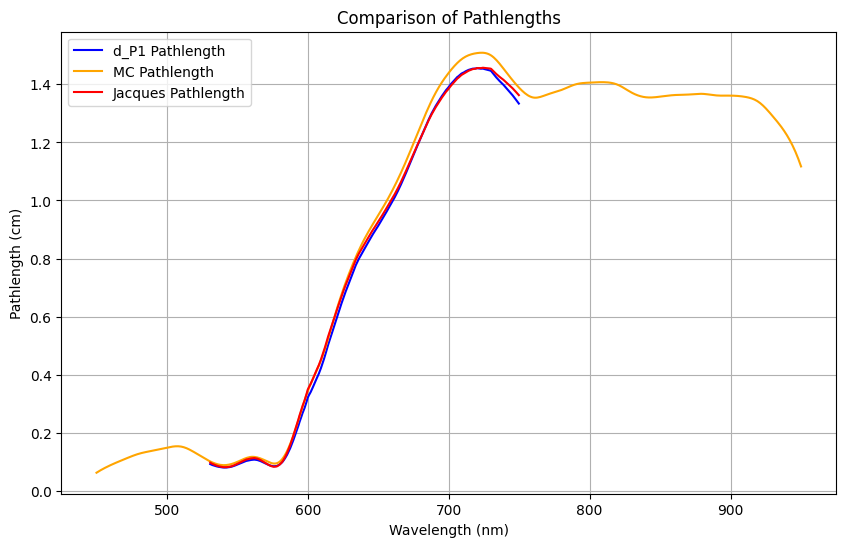

In [5]:
# compare them
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(df['# wavelength_nm'], df['pathlength_cm'], label='d_P1 Pathlength', color='blue')
# careful about key names, they may differ between the two files
plt.plot(df_txt[:, 0], df_txt[:, 1]/10, label='MC Pathlength', color='orange')
# plot pixelwise pathlengths as a band with mean and std
'''
plt.fill_between(df_pixelwise['wavelength_nm'],
                 df_pixelwise['mean_PL'] - df_pixelwise['std_PL'],
                 df_pixelwise['mean_PL'] + df_pixelwise['std_PL'],
                 color='green', alpha=0.3, label='Pixelwise Pathlength (mean ± std)')
'''
# also plot the mean
#plt.plot(df_pixelwise['wavelength_nm'], df_pixelwise['mean_PL'], color='green', label='Pixelwise Pathlength Mean')
plt.plot(df_jacques['wavelength_nm'], df_jacques['mean_PL'], color='red', label='Jacques Pathlength')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Pathlength (cm)')
plt.grid()
plt.title('Comparison of Pathlengths')
plt.legend()

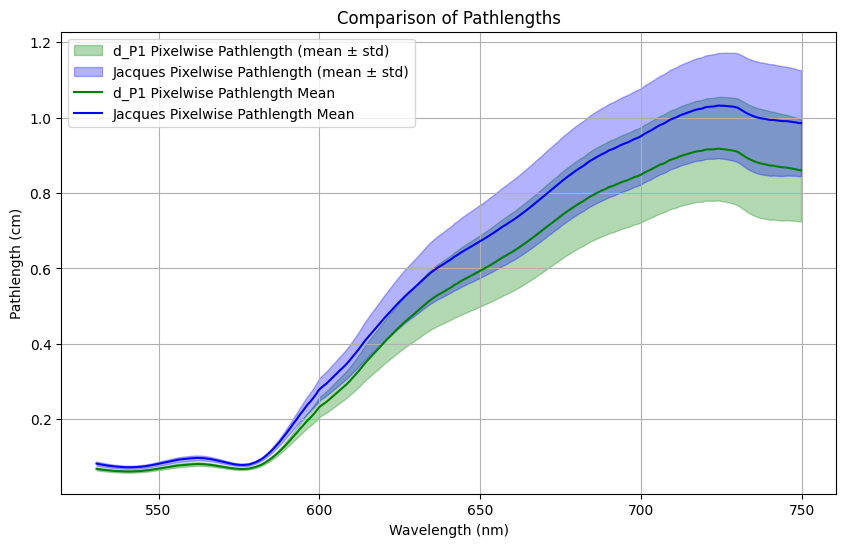

In [14]:
plt.figure(figsize=(10, 6))
plt.fill_between(df_pixelwise['wavelength_nm'],
                 df_pixelwise['mean_PL'] - df_pixelwise['std_PL'],
                 df_pixelwise['mean_PL'] + df_pixelwise['std_PL'],
                 color='green', alpha=0.3, label='d_P1 Pixelwise Pathlength (mean ± std)')
plt.fill_between(df_jacques_pixelwise['wavelength_nm'],
                 df_jacques_pixelwise['mean_PL'] - df_jacques_pixelwise['std_PL'],
                 df_jacques_pixelwise['mean_PL'] + df_jacques_pixelwise['std_PL'],
                 color='blue', alpha=0.3, label='Jacques Pixelwise Pathlength (mean ± std)')
plt.plot(df_pixelwise['wavelength_nm'], df_pixelwise['mean_PL'], color='green', label='d_P1 Pixelwise Pathlength Mean')
plt.plot(df_jacques_pixelwise['wavelength_nm'], df_jacques_pixelwise['mean_PL'], color='blue', label='Jacques Pixelwise Pathlength Mean')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Pathlength (cm)')
plt.grid()
plt.title('Comparison of Pathlengths')
plt.legend()

In [6]:
# load pixel and wavelengthwise pathlengths from npz file
pl_pixel = np.load("/home/cihank/hsi-biopsy/data/pathlengths/012-01_pixelwise_pathlength_debug.npz")

In [ ]:
# see the keys
print("Keys in the npz file:", list(pl_pixel["PL"].shape))

# load gt_map
gt_map = np.load("/home/cihank/hsi-biopsy/results/helicoid_delta_p1_bootstrapped/sample_cache/sample_cache/012-01.npz")["gt_map"]


Keys in the npz file: [443, 497, 302]
(443, 497)


In [17]:
print(gt_map.max())

4


In [18]:
# choose representative pixels from tissue, tumor, blood, and outlier regions
tissue_pixels = pl_pixel["PL"][gt_map == 1]
tumor_pixels = pl_pixel["PL"][gt_map == 2]
blood_pixels = pl_pixel["PL"][gt_map == 3]
background_pixels = pl_pixel["PL"][gt_map == 0]

Text(0.5, 1.0, 'Pathlengths for Representative Pixels in Different Regions')

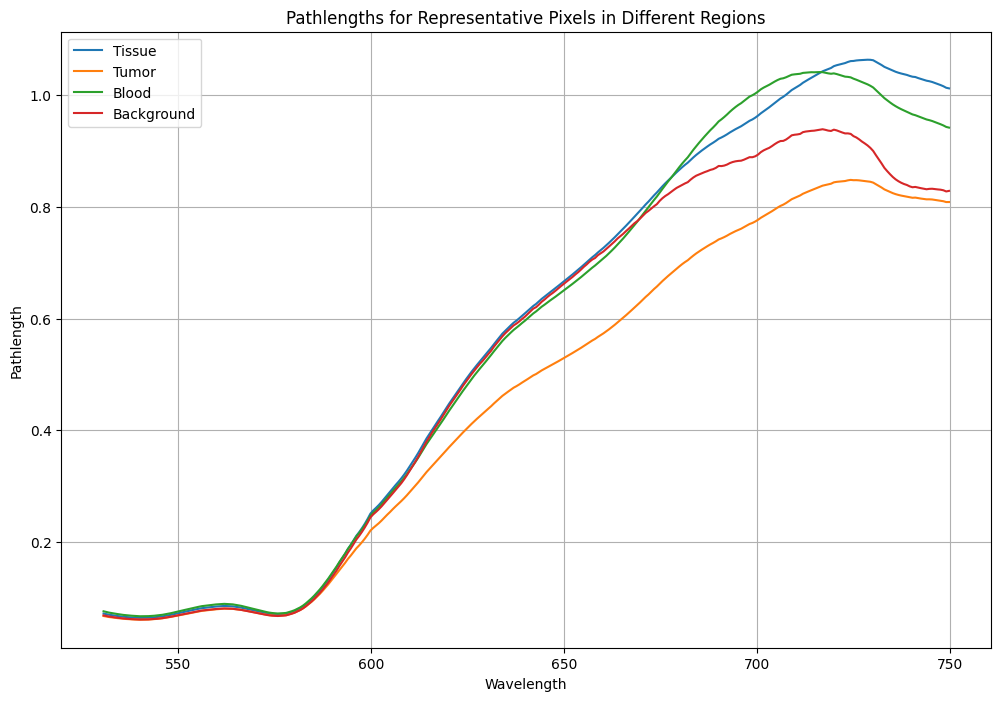

In [23]:
# plot the pathlengths for a pixel for each region
plt.figure(figsize=(12, 8))
plt.plot(pl_pixel["wavelengths"],tissue_pixels[2], label="Tissue")
plt.plot(pl_pixel["wavelengths"],tumor_pixels[2], label="Tumor")
plt.plot(pl_pixel["wavelengths"],blood_pixels[2], label="Blood")
plt.plot(pl_pixel["wavelengths"],background_pixels[2], label="Background")
plt.xlabel("Wavelength")
plt.ylabel("Pathlength")
plt.legend()
plt.grid()
plt.title("Pathlengths for Representative Pixels in Different Regions")

In [16]:
pl_pixel = np.load("/home/cihank/hsi-biopsy/data/pathlengths/012-01_pixelwise_jacques_PL.npz")
gt_map = np.load("/home/cihank/hsi-biopsy/results/helicoid_delta_p1_bootstrapped/sample_cache/sample_cache/012-01.npz")["gt_map"]

tissue_pixels = pl_pixel["PL"][gt_map == 1]
tumor_pixels = pl_pixel["PL"][gt_map == 2]
blood_pixels = pl_pixel["PL"][gt_map == 3]
background_pixels = pl_pixel["PL"][gt_map == 0]

Text(0.5, 1.0, 'Pathlengths for Representative Pixels in Different Regions')

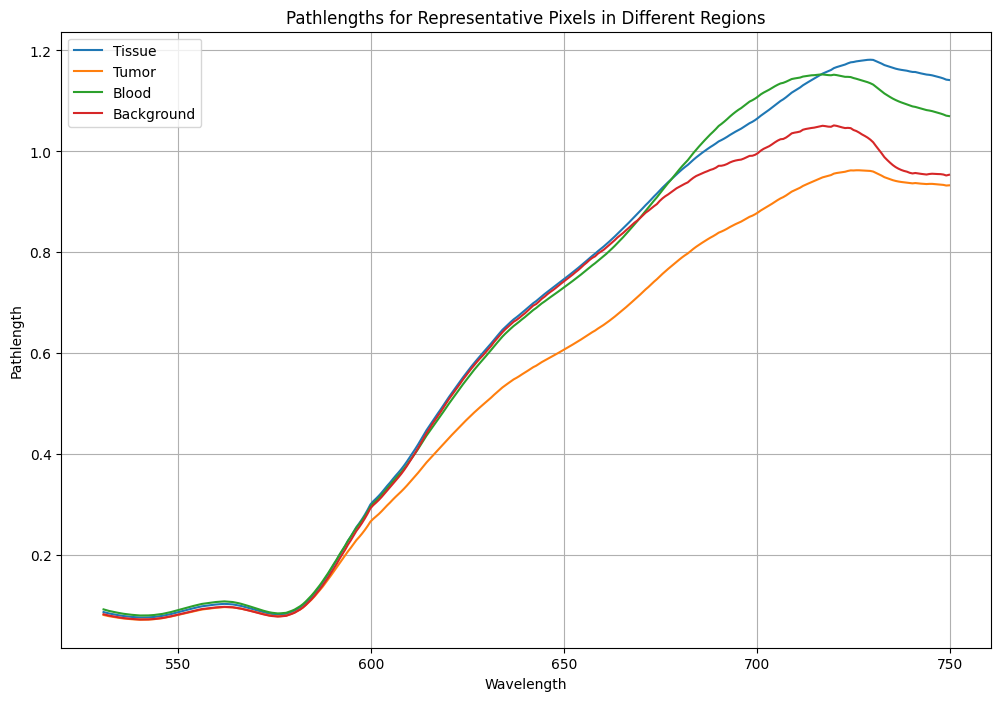

In [17]:
# plot the pathlengths for a pixel for each region
plt.figure(figsize=(12, 8))
plt.plot(pl_pixel["wavelengths"],tissue_pixels[2], label="Tissue")
plt.plot(pl_pixel["wavelengths"],tumor_pixels[2], label="Tumor")
plt.plot(pl_pixel["wavelengths"],blood_pixels[2], label="Blood")
plt.plot(pl_pixel["wavelengths"],background_pixels[2], label="Background")
plt.xlabel("Wavelength")
plt.ylabel("Pathlength")
plt.legend()
plt.grid()
plt.title("Pathlengths for Representative Pixels in Different Regions")

In [31]:
# inspect helicoid molecular maps
mol_map = np.load("/home/cihank/hsi-biopsy/results/helicoid_molecular_maps/reference_params/008-01_coef_list.npy")

(460, 549, 10)


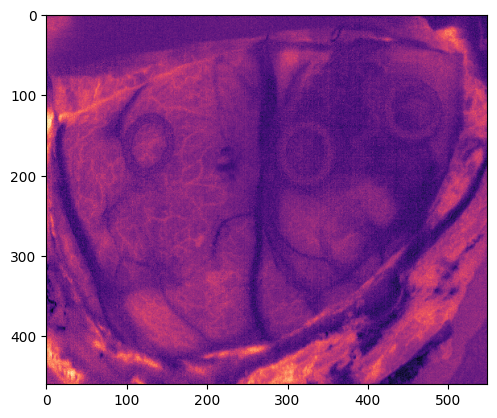

In [34]:
print(mol_map.shape)
# plot it with the colormap magma
plt.imshow(mol_map[:,:,0], cmap='magma')